# Binance 永续 — 两层策略工作台

| 头 | 任务 | 标签 | 输出 |
|---|---|---|---|
| `selection` | 回归 | 未来 **7 日**收益 | 横截面选币分数 |
| `timing` | 二分类 | 次日涨/跌 | **P(次日涨)** |
| `range_high` | 分位数 q90 | 次日最高/今收−1 | **次日最高价** |
| `range_low` | 分位数 q10 | 次日最低/今收−1 | **次日最低价** |

44 个 Binance USDT 永续，**158 个因子**，LightGBM，日频网格 + embargo 隔离，资金费计入 PnL。

每个 cell 只调 `src/` 里的函数。改完 `src/*.py` 直接重跑 cell（autoreload 已开）。

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import config, binance_data as bd, factors as F, models as M
import perp_backtest as pb, perp_inference as pi, perp_plan as pp, perp_pipeline as P

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 60)
print('root    :', config.PROJECT_ROOT)
print('universe:', config.UNIVERSE_SIZE, 'perps | TOP_N', config.TOP_N,
      '| exit rank', config.TOP_N*config.EXIT_RANK_MULT,
      '| timing gate', config.USE_TIMING_GATE)

root    : /Users/haowen/Documents/CryptoQuantPipeline
universe: 50 perps | TOP_N 8 | exit rank 16 | timing gate False


## 1. 数据层

永续 K 线 + 资金费率 + 现货基差。三个运维保护见 README：下载失败不覆盖缓存、自动剔除未收盘当天 bar、现货端点 limit 上限 1000。

In [2]:
frames = bd.load_universe()
info = pd.DataFrame({s: {'bars': len(d), 'start': d.index.min().date(), 'end': d.index.max().date(),
                         'close': d['Close'].iloc[-1],
                         'funding_30d': d['funding_daily'].tail(30).mean()*100}
                     for s, d in frames.items()}).T.sort_values('bars', ascending=False)
print(f"{len(frames)} 个币 | 最新 bar {max(d.index.max() for d in frames.values()).date()} (UTC)")
info.head(10)

44 个币 | 最新 bar 2026-09-19 (UTC)


,bars,start,end,close,funding_30d
1000PEPEUSDT,1095,2023-09-21,2026-09-19,0.004122,0.025275
SUIUSDT,1095,2023-09-21,2026-09-19,0.8574,0.016979
INJUSDT,1095,2023-09-21,2026-09-19,7.925,0.001462
AAVEUSDT,1095,2023-09-21,2026-09-19,141.03,0.01826
LTCUSDT,1095,2023-09-21,2026-09-19,58.28,0.019805
NEARUSDT,1095,2023-09-21,2026-09-19,3.588,0.014514
ONEUSDT,1095,2023-09-21,2026-09-19,0.003936,-0.293384
SOLUSDT,1095,2023-09-21,2026-09-19,111.04,0.009834
TRXUSDT,1095,2023-09-21,2026-09-19,0.33973,-0.040218
FILUSDT,1095,2023-09-21,2026-09-19,0.9611,0.017721


In [3]:
# 单币结构：合约数据比现货多出资金费、笔数、主动买入量、基差
d = frames['BTCUSDT']
show = d[['Close','Volume','Trades','TakerBuyBase','funding_daily','SpotClose']].tail(5).copy()
show['taker_imb'] = (2*d['TakerBuyBase'] - d['Volume'])/d['Volume']
show['basis_bps'] = (d['Close']/d['SpotClose'] - 1)*1e4
show

,Close,Volume,Trades,TakerBuyBase,funding_daily,SpotClose,taker_imb,basis_bps
date,,,,,,,,
2026-09-15,75599.9,238237.286,4986849.0,116080.858,0.000196,75644.48,-0.025502,-5.893358
2026-09-16,76174.6,156286.215,4124224.0,76833.482,0.000120,76206.01,-0.016759,-4.121722
2026-09-17,76385.9,119083.228,2761932.0,59325.990,0.000212,76417.01,-0.003621,-4.071083
2026-09-18,80863.0,220861.332,4486145.0,113802.425,0.000225,80883.87,0.030533,-2.580243
2026-09-19,81225.6,75131.499,1808096.0,37409.048,0.000266,81249.99,-0.004171,-3.001847


## 2. 因子库（158 个）

132 个单币 + 26 个横截面/市场。**从不填充缺失值**——预热期丢弃，长窗口因子保持 NaN，
LightGBM 原生处理。

In [4]:
panel = F.build_panel(frames)
feats = F.feature_columns(panel)

fams = {'A 收益动量':'ret_', 'B 波动':('vol_','parkinson','garman','downside'),
        'C 形态':('hl_range','close_loc','body_','_wick','gap_'),
        'D 趋势':('sma_','ema_','macd','adx_','aroon'),
        'E 振荡':('rsi_','stoch','williams','cci','zscore','bb_'),
        'F 量能':('volume_','log_dollar','obv','mfi','vwap','amihud','turnover','trades_z','avg_trade'),
        'G 主动流':'taker_', 'H 衍生品':('funding_','basis_','perp_spot'),
        'I 横截面':('cs_','mkt_','rel_','beta_','corr_','idio_')}
rows=[]
for name, pre in fams.items():
    pre = (pre,) if isinstance(pre,str) else pre
    cols=[c for c in feats if c.startswith(pre)]
    rows.append({'族':name,'数量':len(cols),'例子':', '.join(cols[:3])})
print(f"总计 {len(feats)} 个特征\n")
pd.DataFrame(rows)

Panel: 38,671 rows | 1,005 dates | 44 symbols | 2023-12-20 -> 2026-09-19
       158 features, 7 labels, median 39 assets/date
总计 158 个特征



,族,数量,例子
0,A 收益动量,12,"ret_1d, ret_2d, ret_3d"
1,B 波动,18,"vol_5d, vol_7d, vol_10d"
2,C 形态,11,"hl_range_5d, hl_range_14d, hl_range_30d"
3,D 趋势,22,"sma_ratio_5d, sma_ratio_10d, sma_ratio_20d"
4,E 振荡,16,"rsi_7d, rsi_14d, rsi_21d"
5,F 量能,19,"volume_z_5d, volume_z_14d, volume_z_30d"
6,G 主动流,8,"taker_imb_1d, taker_imb_3d, taker_imb_7d"
7,H 衍生品,22,"funding_1d, funding_mean_3d, funding_mean_7d"
8,I 横截面,26,"cs_rank_ret_7d, cs_rank_ret_30d, cs_rank_vol_14d"


In [5]:
# 标签：次日/7日收益、涨跌二分类、次日高低点、扣资金费的净收益
panel.xs('BTCUSDT', level='Symbol')[F.LABEL_COLS].tail(4)

,target_ret_7d,target_ret_1d,target_up_1d,target_high_1d,target_low_1d,funding_next_1d,target_net_1d
Date,,,,,,,
2026-09-16,NaN,0.002774,1.0,0.012802,-0.002620,0.000212,0.002562
2026-09-17,NaN,0.058612,1.0,0.065461,-0.001701,0.000225,0.058386
2026-09-18,NaN,0.004484,1.0,0.013243,-0.000747,0.000266,0.004218
2026-09-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. 训练四个头

`WF_STEP` 只影响**验证**，不影响生产模型。10 约 6 分钟，20 约 3 分钟。

分位数头会自动做**保形校准**：纯分位数回归在波动扩张时系统性覆盖不足，
校准后覆盖率回到名义水平。

In [6]:
WF_STEP = 20    # 迭代用 20；出正式结论用 ≤10
results = M.train_all(panel, wf_step=WF_STEP)

Walk-forward validation:


  [selection] MSE 0.035621 | RankIC +0.0245 (t=+3.25) | hit 0.502 | n=30,094  (37 folds, refit/20d)


  [timing] AUC 0.5280 | acc 0.5241 | Brier 0.2725 | logloss 0.7503 | base 0.483 vs pred 0.490 | n=30,568  (38 folds, refit/20d)


  [range_high] pinball 0.01050 | coverage 0.847 (target 0.90) | mean pred +0.0718 | n=30,568  (38 folds, refit/20d)
      conformal delta +0.01454 -> coverage 0.847 => 0.903 (target 0.90)


  [range_low] pinball 0.00828 | coverage 0.182 (target 0.10) | mean pred -0.0621 | n=30,568  (38 folds, refit/20d)
      conformal delta -0.01459 -> coverage 0.182 => 0.102 (target 0.10)


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (name, res) in zip(axes.ravel(), results.items()):
    imp = res['importances'].head(14).sort_values('Gain')
    ax.barh(imp['Feature'], imp['Gain'], color='steelblue')
    ax.set_title(f"{name}", fontweight='bold'); ax.grid(axis='x', ls=':', alpha=.5)
    ax.tick_params(labelsize=8)
plt.tight_layout()

## 4. 回测

日频结算，扣 `COST_BPS` 手续费**和真实资金费**。对照组里最关键的是 `Selection (daily rebal)` 和 `Selection + Timing gate`。


Backtest (top 8, exit below rank 16, 10bps + funding)


                        Total Return     CAGR Ann. Vol  Sharpe Max Drawdown Win Rate Avg Turnover Days Invested Funding Drag Fee Drag  Days
Selection + Hysteresis       +99.66%  +40.71%  +79.17%  +0.824      -61.55%  +51.29%       +0.250      +100.00%       -1.80%  +18.45%   739
Selection (daily rebal)      +92.04%  +38.03%  +79.49%  +0.800      -62.21%  +50.88%       +0.606      +100.00%       -3.04%  +44.75%   739
Selection + Timing gate       +3.23%   +1.58%  +76.77%  +0.403      -64.42%  +37.89%       +0.955       +74.56%       -6.78%  +70.57%   739
Timing only                  +14.55%   +6.94%  +72.48%  +0.455      -58.41%  +42.63%       +1.134       +82.81%       -3.20%  +83.77%   739
Equal-Weight (all)           +43.30%  +19.45%  +71.25%  +0.608      -68.19%  +51.01%       +0.002      +100.00%       +0.31%   +0.15%   739
BTCUSDT Buy&Hold             +19.33%   +9.12%  +44.22%  +0.418      -53.72%  +49.80%       +0.001      +100.00%      +10.41%   +0.10%   739
Backtest plot saved 

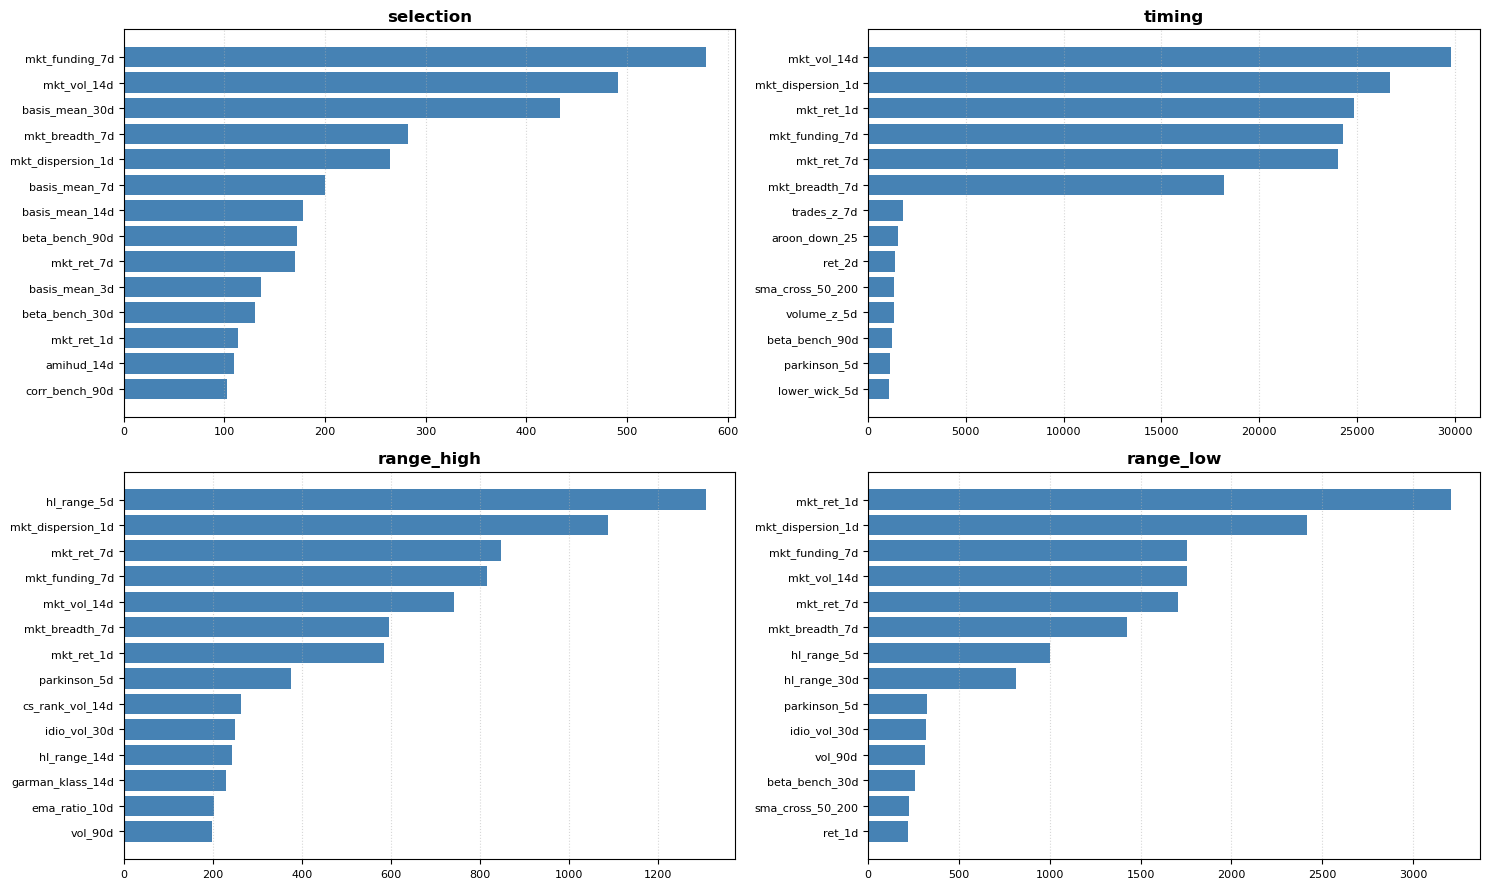

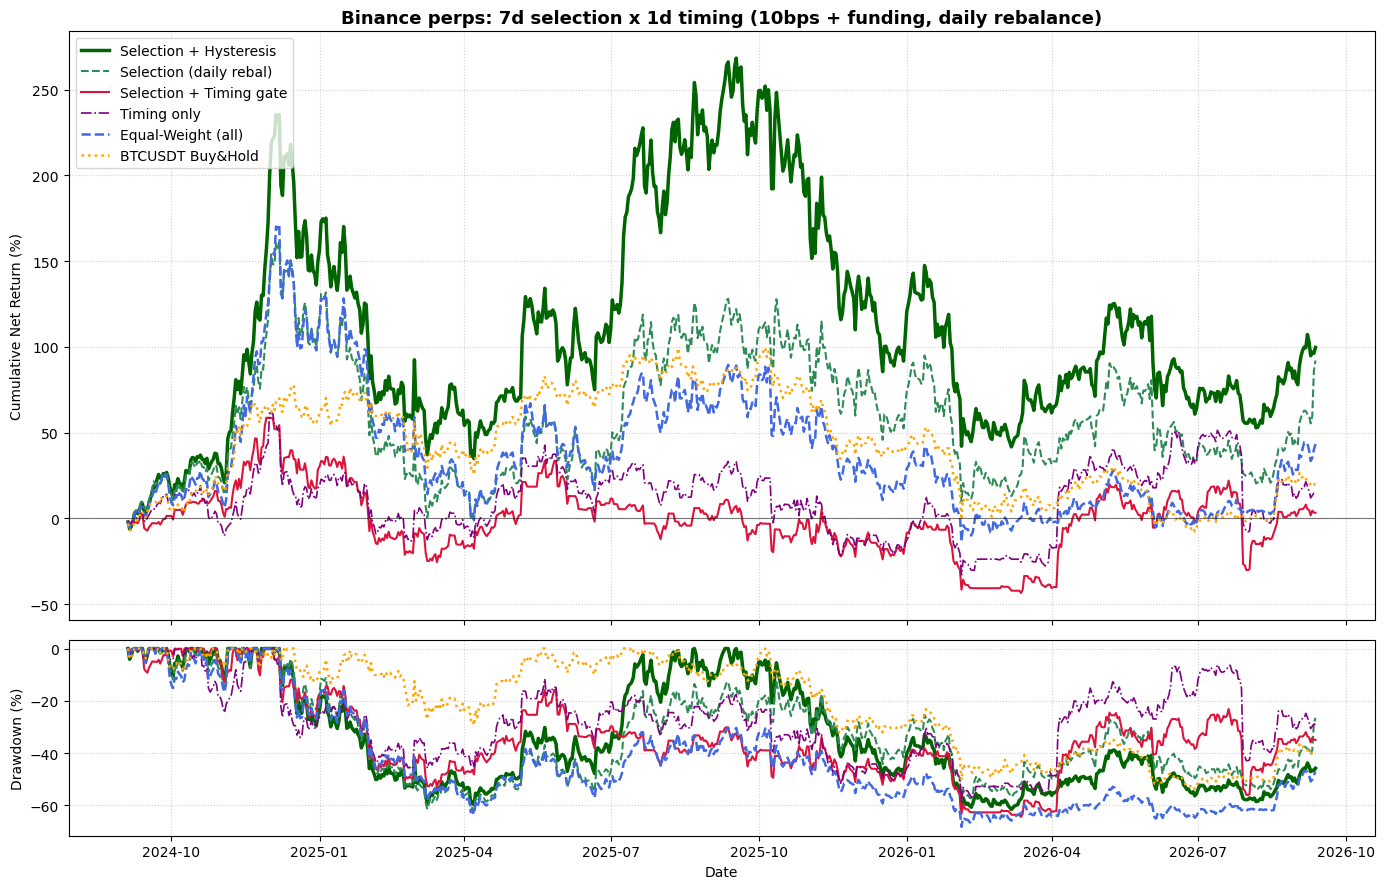

In [8]:
signals_bt, summary, curves, fig = P.backtest(results, show_plot=True)

## 5. 为什么择时闸门默认关闭

`P(次日涨)` 是校准过的、也确实输出了，但拿它当每日开关会把策略打崩。
原因不是概率没用，是**选币层的优势在右尾，不在胜率**。

In [9]:
s = signals_bt.copy()
s['sel_rank'] = s.groupby('Date')['sel_score'].rank(ascending=False)
top, rest = s[s.sel_rank<=config.TOP_N], s[s.sel_rank>config.TOP_N]

print('选币 top8 vs 其余（walk-forward 全样本）')
print(f"  次日上涨频率  : {(top.target_ret_1d>0).mean():.3f}  vs  {(rest.target_ret_1d>0).mean():.3f}")
print(f"  次日收益均值  : {top.target_ret_1d.mean():+.5f}  vs  {rest.target_ret_1d.mean():+.5f}")
print(f"  次日收益中位数: {top.target_ret_1d.median():+.5f}  vs  {rest.target_ret_1d.median():+.5f}   <- 中位数为负")
print(f"  偏度          : {top.target_ret_1d.skew():+.2f}  vs  {rest.target_ret_1d.skew():+.2f}   <- 右尾很厚")

t = top.copy()
t['bucket'] = pd.cut(t.prob_up, [0,.45,.50,.55,1], labels=['<45%','45-50%','50-55%','>55%'])
g = t.groupby('bucket', observed=True)['target_ret_1d'].agg(n='size', 平均收益='mean',
                                                            上涨频率=lambda x:(x>0).mean())
print('\n按 P(up) 分档看 top8 的次日实际收益（概率和期望收益几乎正交）:')
g.style.format({'平均收益':'{:+.4%}','上涨频率':'{:.1%}'})

选币 top8 vs 其余（walk-forward 全样本）
  次日上涨频率  : 0.485  vs  0.480
  次日收益均值  : +0.00231  vs  +0.00080
  次日收益中位数: -0.00101  vs  -0.00154   <- 中位数为负
  偏度          : +3.56  vs  +2.52   <- 右尾很厚

按 P(up) 分档看 top8 的次日实际收益（概率和期望收益几乎正交）:


,n,平均收益,上涨频率
bucket,,,
<45%,2258,+0.1181%,46.5%
45-50%,606,+0.3787%,49.7%
50-55%,614,-0.5130%,43.0%
>55%,2434,+0.4858%,51.4%


## 6. 参数敏感度

注意这是在**同一段历史**上反复搜索，把它当敏感度分析，不是调参结果。

In [10]:
rows=[]
for n in [3,5,8,10,15]:
    for mult in [1,2,3]:
        m = pb.metrics(pb.simulate(signals_bt, pb.rule_selection_hysteresis,
                                   top_n=n, exit_rank_mult=mult))
        rows.append({'top_n':n,'exit_mult':mult,'Total':m['Total Return'],'Sharpe':m['Sharpe'],
                     'MaxDD':m['Max Drawdown'],'Turnover':m['Avg Turnover'],'Fee':m['Fee Drag']})
sweep = pd.DataFrame(rows)
display(sweep.pivot(index='top_n', columns='exit_mult', values='Sharpe')
        .style.format('{:+.3f}').background_gradient(cmap='RdYlGn', axis=None).set_caption('Sharpe'))
sweep.style.format({'Total':'{:+.1%}','Sharpe':'{:+.3f}','MaxDD':'{:+.1%}',
                    'Turnover':'{:.2f}','Fee':'{:+.1%}'}).hide(axis='index')

exit_mult,1,2,3
top_n,,,
3,+0.702,+0.720,+0.912
5,+0.667,+0.916,+0.604
8,+0.800,+0.824,+0.684
10,+0.633,+1.038,+0.681
15,+0.457,+0.657,+0.446


top_n,exit_mult,Total,Sharpe,MaxDD,Turnover,Fee
3,1,+58.2%,+0.702,-76.2%,0.80,+59.0%
3,2,+64.6%,+0.720,-82.5%,0.41,+30.0%
3,3,+137.5%,+0.912,-78.1%,0.30,+22.3%
5,1,+53.4%,+0.667,-71.0%,0.68,+50.3%
5,2,+134.8%,+0.916,-62.7%,0.34,+24.9%
5,3,+38.1%,+0.604,-77.7%,0.22,+16.4%
8,1,+92.0%,+0.800,-62.2%,0.61,+44.8%
8,2,+99.7%,+0.824,-61.5%,0.25,+18.4%
8,3,+59.6%,+0.684,-67.9%,0.15,+11.1%
10,1,+47.8%,+0.633,-64.6%,0.58,+42.8%


In [11]:
# 手续费假设敏感度 —— 为什么默认用迟滞而不是日频调仓
rows=[]
for c in [2,5,10,15,20,30]:
    h = pb.metrics(pb.simulate(signals_bt, pb.rule_selection_hysteresis, cost_bps=c,
                               top_n=config.TOP_N, exit_rank_mult=config.EXIT_RANK_MULT))
    dd = pb.metrics(pb.simulate(signals_bt, pb.rule_selection_only, cost_bps=c, top_n=config.TOP_N))
    rows.append({'cost_bps':c,'迟滞':h['Total Return'],'迟滞Sharpe':h['Sharpe'],
                 '日频调仓':dd['Total Return'],'日频Sharpe':dd['Sharpe']})
pd.DataFrame(rows).style.format({'迟滞':'{:+.0%}','日频调仓':'{:+.0%}',
                                 '迟滞Sharpe':'{:+.2f}','日频Sharpe':'{:+.2f}'}).hide(axis='index')

cost_bps,迟滞,迟滞Sharpe,日频调仓,日频Sharpe
2,+131%,+0.92,+175%,+1.02
5,+119%,+0.88,+140%,+0.94
10,+100%,+0.82,+92%,+0.80
15,+82%,+0.77,+54%,+0.66
20,+66%,+0.71,+23%,+0.52
30,+38%,+0.59,-22%,+0.24


## 7. 今晚的预测

三个输出：7 日选币分数、**P(次日涨)**、**次日最高/最低价区间**。

In [12]:
_prev, _date, prev_holdings = pp.load_previous_plan(panel.index.get_level_values('Date').max())
signals, held, meta = pi.generate_signals(panel, prev_holdings=prev_holdings)

print(f"as of {pd.Timestamp(meta['as_of']).date()} (UTC 收盘) | {meta['n_universe']} 币 | {meta['n_features']} 特征")
print(f"区间校准: {meta['conformal']}")
pi.format_signals(signals, 15)

as of 2026-09-19 (UTC 收盘) | 44 币 | 158 特征
区间校准: {'range_high': {'delta': 0.014541775760855314, 'raw_coverage': 0.8468660036639624, 'calibrated_coverage': 0.9032975660821775, 'target_coverage': 0.9, 'calib_rows': 11044}, 'range_low': {'delta': -0.014586073504292668, 'raw_coverage': 0.18221669719968595, 'calibrated_coverage': 0.10154409840355928, 'target_coverage': 0.1, 'calib_rows': 11044}}


,Rank,Symbol,Close,P(up),Exp7d,Low,High,Band,Decision
0,1,ONEUSDT,0.003936,30.4%,+23.44%,0.00286801,0.00656624,94.0%,ENTER
1,2,GUSDT,0.010569,47.6%,+19.88%,0.00817095,0.0172873,86.3%,ENTER
2,3,ZILUSDT,0.003567,40.3%,+17.04%,0.00316952,0.00472108,43.5%,ENTER
3,4,CELRUSDT,0.003346,39.0%,+15.99%,0.00278655,0.00489263,62.9%,ENTER
4,5,BNBUSDT,762.52,68.5%,+12.80%,733.512,824.115,11.9%,ENTER
5,6,TRXUSDT,0.33973,64.6%,+12.44%,0.331342,0.362324,9.1%,ENTER
6,7,1000PEPEUSDT,0.0041222,48.2%,+12.23%,0.00373945,0.00496765,29.8%,ENTER
7,8,ARUSDT,4.412,38.2%,+12.15%,3.71019,6.29393,58.6%,ENTER
8,9,B2USDT,0.5234,39.7%,+11.47%,0.447492,0.70041,48.3%,WATCH
9,10,LINKUSDT,12.416,55.4%,+11.26%,11.6366,14.3897,22.2%,WATCH


In [13]:
# 次日价格区间可视化（前 12 名）
top12 = signals.head(12)
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(top12))
ax.vlines(x, top12['low_price']/top12['Close']-1, top12['high_price']/top12['Close']-1,
          color='steelblue', lw=6, alpha=.55, label='次日 80% 预测区间')
ax.scatter(x, np.zeros(len(x)), color='black', zorder=3, s=25, label='今收')
for i, (_, r) in enumerate(top12.iterrows()):
    ax.annotate(f"{r['prob_up_1d']:.0%}", (i, r['high_price']/r['Close']-1),
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(top12['Symbol'], rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='black', lw=.8); ax.set_ylabel('相对今收的幅度')
ax.set_title('次日价格区间（标注为 P(次日涨)）', fontweight='bold')
ax.grid(axis='y', ls=':', alpha=.6); ax.legend(); plt.tight_layout()

## 8. 交易计划

仓位规则是**迟滞**：进 top N，跌出 top N×mult 才卖。规则**路径依赖**——
今晚持什么取决于昨晚持什么，所以 `output/plans/` 里的上一份计划必须反映真实持仓。

In [14]:
plan, orders = pp.build_plan(signals, held, meta, save=True)
for k, v in pp.plan_summary(plan, meta).items():
    print(f"{k:<26} {v}")
display(pp.format_plan(plan, 15))
print('\n下单清单:')
display(orders if not orders.empty else '与上一份计划无变化')

Plan saved to /Users/haowen/Documents/CryptoQuantPipeline/output/plans/plan_2026-09-19.csv
As of (UTC bar close)      2026-09-19
Universe                   44 symbols
Rule                       top 8, exit below rank 16  (timing gate OFF)
Holding                    8 (ONEUSDT, GUSDT, ZILUSDT, CELRUSDT, BNBUSDT, TRXUSDT, 1000PEPEUSDT, ARUSDT)
Gross exposure             10,000 / 10,000 (100%)
Turnover vs prev plan      1.00 (~10.00 in fees)
Prev plan                  none
Range calibration          high 90.3%/90%, low 10.2%/10%


,Symbol,Rank,Decision,Action,Exp7d,P(up),Weight,Notional,Ref,PredLow,PredHigh
0,ONEUSDT,1,ENTER,BUY (open),+23.44%,30.4%,12.5%,"1,250",0.003936,0.00286801,0.00656624
1,GUSDT,2,ENTER,BUY (open),+19.88%,47.6%,12.5%,"1,250",0.010569,0.00817095,0.0172873
2,ZILUSDT,3,ENTER,BUY (open),+17.04%,40.3%,12.5%,"1,250",0.003567,0.00316952,0.00472108
3,CELRUSDT,4,ENTER,BUY (open),+15.99%,39.0%,12.5%,"1,250",0.003346,0.00278655,0.00489263
4,BNBUSDT,5,ENTER,BUY (open),+12.80%,68.5%,12.5%,"1,250",762.52,733.512,824.115
5,TRXUSDT,6,ENTER,BUY (open),+12.44%,64.6%,12.5%,"1,250",0.33973,0.331342,0.362324
6,1000PEPEUSDT,7,ENTER,BUY (open),+12.23%,48.2%,12.5%,"1,250",0.0041222,0.00373945,0.00496765
7,ARUSDT,8,ENTER,BUY (open),+12.15%,38.2%,12.5%,"1,250",4.412,3.71019,6.29393
8,B2USDT,9,WATCH,FLAT,+11.47%,39.7%,0.0%,0,0.5234,0.447492,0.70041
9,LINKUSDT,10,WATCH,FLAT,+11.26%,55.4%,0.0%,0,12.416,11.6366,14.3897



下单清单:


,Symbol,Action,Delta_Weight,Delta_Notional,Ref_Price,Prob_Up_1d,Pred_Low_1d,Pred_High_1d
0,ONEUSDT,BUY (open),0.125,1250.0,0.003936,0.303738,0.002868,0.006566
1,GUSDT,BUY (open),0.125,1250.0,0.010569,0.475919,0.008171,0.017287
2,ZILUSDT,BUY (open),0.125,1250.0,0.003567,0.402753,0.003170,0.004721
3,CELRUSDT,BUY (open),0.125,1250.0,0.003346,0.389809,0.002787,0.004893
4,BNBUSDT,BUY (open),0.125,1250.0,762.520000,0.684855,733.511966,824.114746
5,TRXUSDT,BUY (open),0.125,1250.0,0.339730,0.646410,0.331342,0.362324
6,1000PEPEUSDT,BUY (open),0.125,1250.0,0.004122,0.482321,0.003739,0.004968
7,ARUSDT,BUY (open),0.125,1250.0,4.412000,0.382155,3.710192,6.293931


## 9. 一键夜跑

等价于命令行 `python main.py nightly`（约 1 分钟：刷新 → 重训生产模型 → 预测 → 计划）。

完整验证走 `python main.py backtest`（约 6 分钟），每周一次即可——
多一天数据对 walk-forward 的边际价值接近零，但分位数头的保形校准需要它。

In [15]:
out = P.run_nightly(refresh=False, collect_short=False)
out['orders']

Project root: /Users/haowen/Documents/CryptoQuantPipeline
Loaded 44 symbols | latest bar 2026-09-19

Building factor panel


Panel: 38,671 rows | 1,005 dates | 44 symbols | 2023-12-20 -> 2026-09-19
       158 features, 7 labels, median 39 assets/date

Training LightGBM heads (production refit only)
Production refit only:



Tonight's forecast
as of 2026-09-19 (UTC bar close) | 44 symbols | 158 features

--- Next-day forecast (top 15 by 7d selection score) ---
 Rank       Symbol     Close P(up)   Exp7d        Low       High  Band Decision
    1      ONEUSDT  0.003936 30.4% +23.44% 0.00286801 0.00656624 94.0%    ENTER
    2        GUSDT  0.010569 47.6% +19.88% 0.00817095  0.0172873 86.3%    ENTER
    3      ZILUSDT  0.003567 40.3% +17.04% 0.00316952 0.00472108 43.5%    ENTER
    4     CELRUSDT  0.003346 39.0% +15.99% 0.00278655 0.00489263 62.9%    ENTER
    5      BNBUSDT    762.52 68.5% +12.80%    733.512    824.115 11.9%    ENTER
    6      TRXUSDT   0.33973 64.6% +12.44%   0.331342   0.362324  9.1%    ENTER
    7 1000PEPEUSDT 0.0041222 48.2% +12.23% 0.00373945 0.00496765 29.8%    ENTER
    8       ARUSDT     4.412 38.2% +12.15%    3.71019    6.29393 58.6%    ENTER
    9       B2USDT    0.5234 39.7% +11.47%   0.447492    0.70041 48.3%    WATCH
   10     LINKUSDT    12.416 55.4% +11.26%    11.6366    14.3

,Symbol,Action,Delta_Weight,Delta_Notional,Ref_Price,Prob_Up_1d,Pred_Low_1d,Pred_High_1d
0,ONEUSDT,BUY (open),0.125,1250.0,0.003936,0.303738,0.002868,0.006566
1,GUSDT,BUY (open),0.125,1250.0,0.010569,0.475919,0.008171,0.017287
2,ZILUSDT,BUY (open),0.125,1250.0,0.003567,0.402753,0.003170,0.004721
3,CELRUSDT,BUY (open),0.125,1250.0,0.003346,0.389809,0.002787,0.004893
4,BNBUSDT,BUY (open),0.125,1250.0,762.520000,0.684855,733.511966,824.114746
5,TRXUSDT,BUY (open),0.125,1250.0,0.339730,0.646410,0.331342,0.362324
6,1000PEPEUSDT,BUY (open),0.125,1250.0,0.004122,0.482321,0.003739,0.004968
7,ARUSDT,BUY (open),0.125,1250.0,4.412000,0.382155,3.710192,6.293931


## 10. 轨道二：短历史合约因子

Binance 对持仓量和多空比**只给 30 天**历史，无法回测。采集器每晚把当前窗口并进本地库，
攒够（约 400 天）后就能接进因子层。

In [16]:
import os
if os.path.exists(config.SHORT_HISTORY_PATH):
    sh = pd.read_parquet(config.SHORT_HISTORY_PATH)
    span = (sh.date.max()-sh.date.min()).days
    print(f"{len(sh):,} 行 | {sh.symbol.nunique()} 币 | {sh.date.min().date()} -> {sh.date.max().date()} ({span} 天)")
    print(f"距离可用（400 天）还差约 {max(0, 400-span)} 天\n")
    display(sh.groupby('metric').agg(行数=('value','size'), 币数=('symbol','nunique')))
    piv = sh[sh.metric=='open_interest'].pivot_table(index='date', columns='symbol', values='value')
    (piv[['BTCUSDT','ETHUSDT','SOLUSDT']]/piv[['BTCUSDT','ETHUSDT','SOLUSDT']].iloc[0]).plot(
        figsize=(12,3.5), title='持仓量（归一化，仅 30 天窗口）', grid=True)
else:
    print('还没采集过。跑 python main.py nightly 或 bd.collect_short_history()')

6,820 行 | 44 币 | 2026-08-20 -> 2026-09-20 (31 天)
距离可用（400 天）还差约 369 天



,行数,币数
metric,,
global_account_ratio,1364,44
open_interest,1364,44
taker_ls_ratio,1364,44
top_account_ratio,1364,44
top_position_ratio,1364,44


## 11. 已知局限

1. **幸存者偏差**：币种池按**今天**的成交量选，再回测两年。当时不火的、已死的币都不在里面。
   这会系统性抬高回测收益，幅度难量化但**一定为正**。
2. **不含滑点和冲击成本**。小市值币（ONEUSDT、ZILUSDT 这类）实际滑点可能远超 10bps。
3. **只做多、不加杠杆、永远满仓**。永续能做空但完全没利用——最明显的未开发空间。
4. **样本短**：739 个回测日 ≈ 2 年。Sharpe 0.78 的置信区间约 ±0.5。
5. **参数扫描会过拟合**：第 6 节在同一段历史上反复搜索。top_n=3 和 8 都约 +106%、
   5 只有 +63%——这个非单调性本身就说明噪声很大。
6. **7 日标签重叠**已用 embargo 处理，但相邻行仍高度相关，有效样本量远小于行数，
   RankIC 的 t 值偏乐观。
7. **价格区间不是止损位**，回测里从未执行过。
8. **模型每晚覆盖 joblib**，没有版本管理。